it begins from here

In [2]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import KFold
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import load_model

In [3]:
# ==========================
# 1️⃣ Load and Preprocess Data
# ==========================
def load_dataset(directory):
    X, y = [], []
    classes = sorted(os.listdir(directory))
    for label in classes:
        class_dir = os.path.join(directory, label)
        if not os.path.isdir(class_dir):
            continue
        for img_file in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_file)
            img = load_img(img_path, target_size=(224, 224))
            img = img_to_array(img) / 255.0
            X.append(img)
            y.append(label)
    return np.array(X), np.array(y), classes



In [4]:
train_dir = "Brain_Tumor_data/Training"
X, y, class_names = load_dataset(train_dir)

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
y_cat = to_categorical(y_encoded, num_classes=len(class_names))

print(f"[INFO] Loaded {len(X)} images across {len(class_names)} classes: {class_names}")

[INFO] Loaded 5712 images across 4 classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [5]:
# ==========================
# 2️⃣ Define CNN Model
# ==========================
def build_cnn(input_shape, num_classes):
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
        MaxPooling2D(2,2),
        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D(2,2),
        Conv2D(128, (3,3), activation='relu'),
        MaxPooling2D(2,2),
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [7]:
# ==========================
# 3️⃣ K-Fold Cross Validation
# ==========================
kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_no = 1
fold_accuracies = []

for train_index, val_index in kf.split(X):
    print(f"\n[INFO] Training Fold {fold_no}...")
    X_train, X_val = X[train_index], X[val_index]
    y_train, y_val = y_cat[train_index], y_cat[val_index]

    model = build_cnn((224, 224, 3), len(class_names))
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=10,
        batch_size=32,
        verbose=1
    )

    acc = np.max(history.history['val_accuracy'])
    fold_accuracies.append(acc)
    model.save(f"classical_cnn_fold{fold_no}.keras")
    print(f"[INFO] Fold {fold_no} Accuracy: {acc:.4f}")
    fold_no += 1



[INFO] Training Fold 1...


c:\Users\hassa\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 63s 426ms/step - accuracy: 0.5307 - loss: 1.0442 - val_accuracy: 0.8329 - val_loss: 0.5366
Epoch 2/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 58s 407ms/step - accuracy: 0.7958 - loss: 0.5579 - val_accuracy: 0.8443 - val_loss: 0.4096
Epoch 3/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 54s 377ms/step - accuracy: 0.8475 - loss: 0.4208 - val_accuracy: 0.8793 - val_loss: 0.3324
Epoch 4/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 57s 397ms/step - accuracy: 0.8774 - loss: 0.3377 - val_accuracy: 0.8898 - val_loss: 0.3013
Epoch 5/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 55s 386ms/step - accuracy: 0.9029 - loss: 0.2728 - val_accuracy: 0.9020 - val_loss: 0.2584
Epoch 6/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 58s 403ms/step - accuracy: 0.9232 - loss: 0.2245 - val_accuracy: 0.9125 - val_loss: 0.2524
Epoch 7/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 56s 395ms/step - accuracy: 0.9304 - loss: 0.2020 - val_accuracy: 0.9204 - val_loss: 0.2267
Epoch 8/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 55s 385ms/step - accuracy: 0.9457 - loss: 0

In [8]:
mean_acc = np.mean(fold_accuracies)
print(f"\n✅ Mean K-Fold Validation Accuracy: {mean_acc:.4f}")


✅ Mean K-Fold Validation Accuracy: 0.9268


In [9]:
model.save(f"classical_cnn_complete.keras")

Model Evaluation Begins

In [10]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
import shap
import glob
# =======================================================
# 1️⃣ Load Test Dataset
# =======================================================
test_dir = "Brain_tumor_data/Testing"

# Use the same image generator for loading test data
datagen = ImageDataGenerator(rescale=1./255)
test_data = datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

class_labels = list(test_data.class_indices.keys())
print(f"[INFO] Found {len(test_data.filenames)} test images in {len(class_labels)} classes: {class_labels}")

Found 1311 images belonging to 4 classes.
[INFO] Found 1311 test images in 4 classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [12]:
# =======================================================
# 2️⃣ Load Trained Models
# =======================================================
models = {}
results = {}

# Load all Classical CNN models saved during K-Fold training
classical_models = sorted(glob.glob("classical_cnn_fold*.keras"))
for i, path in enumerate(classical_models):
    name = f"Classical CNN (Fold {i+1})"
    try:
        models[name] = load_model(path)
        print(f"[INFO] Loaded {name} from {path}")
    except Exception as e:
        print(f"[ERROR] Could not load {name}: {e}")

# Placeholder for Federated Models (Replace with your actual paths when available)
# federated_models_paths = ["federated_client_0.keras", "federated_client_1.keras"]
# for i, path in enumerate(federated_models_paths):
#     name = f"Federated CNN (Client {i})"
#     try:
#         models[name] = load_model(path)
#         print(f"[INFO] Loaded {name} from {path}")
#     except Exception:
#         print(f"[WARNING] Skipping Federated Model {i} as file not found: {path}")

if not models:
    print("\n[FATAL] No models were loaded. Ensure K-Fold training was run successfully.")
    # Exit or create a dummy model to prevent errors

[INFO] Loaded Classical CNN (Fold 1) from classical_cnn_fold1.keras
[INFO] Loaded Classical CNN (Fold 2) from classical_cnn_fold2.keras
[INFO] Loaded Classical CNN (Fold 3) from classical_cnn_fold3.keras
[INFO] Loaded Classical CNN (Fold 4) from classical_cnn_fold4.keras
[INFO] Loaded Classical CNN (Fold 5) from classical_cnn_fold5.keras



🔍 Evaluating Classical CNN (Fold 1) ...
 1/41 ━━━━━━━━━━━━━━━━━━━━ 11s 295ms/step

c:\Users\hassa\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


41/41 ━━━━━━━━━━━━━━━━━━━━ 15s 378ms/step
Classical CNN (Fold 1) Test Accuracy: 0.9191

Classification Report:
              precision    recall  f1-score   support

      glioma       0.89      0.91      0.90       300
  meningioma       0.88      0.77      0.82       306
     notumor       0.96      0.99      0.97       405
   pituitary       0.93      0.99      0.96       300

    accuracy                           0.92      1311
   macro avg       0.91      0.91      0.91      1311
weighted avg       0.92      0.92      0.92      1311



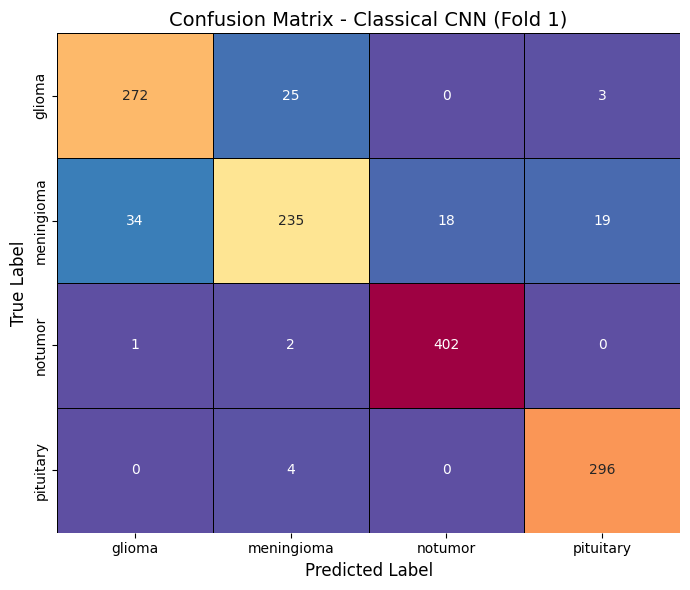


🔍 Evaluating Classical CNN (Fold 2) ...
41/41 ━━━━━━━━━━━━━━━━━━━━ 5s 110ms/step
Classical CNN (Fold 2) Test Accuracy: 0.9458

Classification Report:
              precision    recall  f1-score   support

      glioma       0.92      0.92      0.92       300
  meningioma       0.91      0.87      0.89       306
     notumor       0.97      1.00      0.98       405
   pituitary       0.97      0.99      0.98       300

    accuracy                           0.95      1311
   macro avg       0.94      0.94      0.94      1311
weighted avg       0.95      0.95      0.95      1311



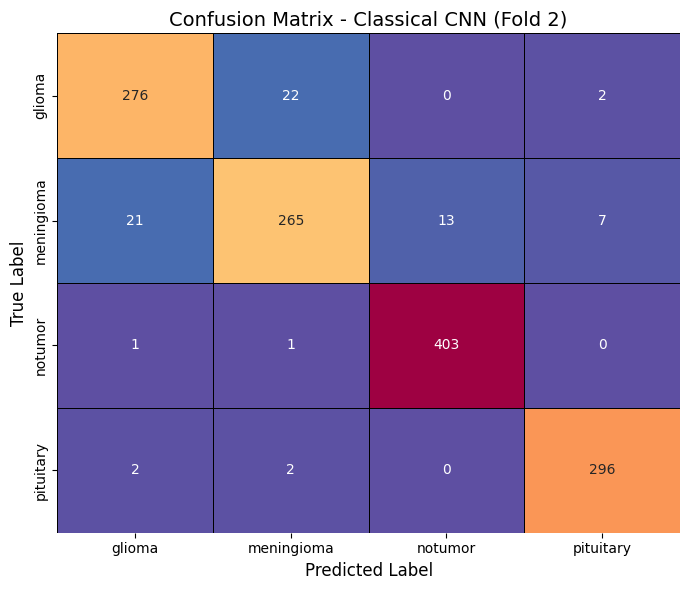


🔍 Evaluating Classical CNN (Fold 3) ...
41/41 ━━━━━━━━━━━━━━━━━━━━ 5s 110ms/step
Classical CNN (Fold 3) Test Accuracy: 0.9321

Classification Report:
              precision    recall  f1-score   support

      glioma       0.97      0.85      0.90       300
  meningioma       0.85      0.88      0.86       306
     notumor       0.95      0.99      0.97       405
   pituitary       0.97      0.99      0.98       300

    accuracy                           0.93      1311
   macro avg       0.93      0.93      0.93      1311
weighted avg       0.93      0.93      0.93      1311



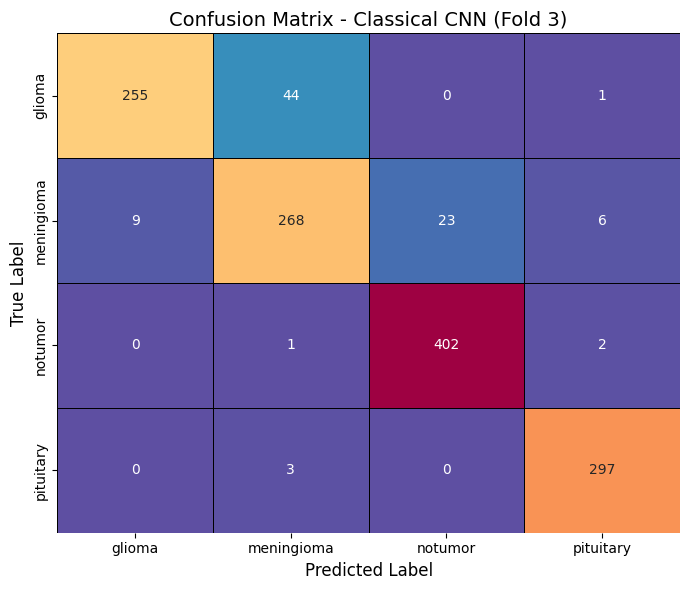


🔍 Evaluating Classical CNN (Fold 4) ...
41/41 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step
Classical CNN (Fold 4) Test Accuracy: 0.9222

Classification Report:
              precision    recall  f1-score   support

      glioma       0.97      0.81      0.88       300
  meningioma       0.82      0.91      0.86       306
     notumor       0.97      0.99      0.98       405
   pituitary       0.94      0.97      0.95       300

    accuracy                           0.92      1311
   macro avg       0.92      0.92      0.92      1311
weighted avg       0.93      0.92      0.92      1311



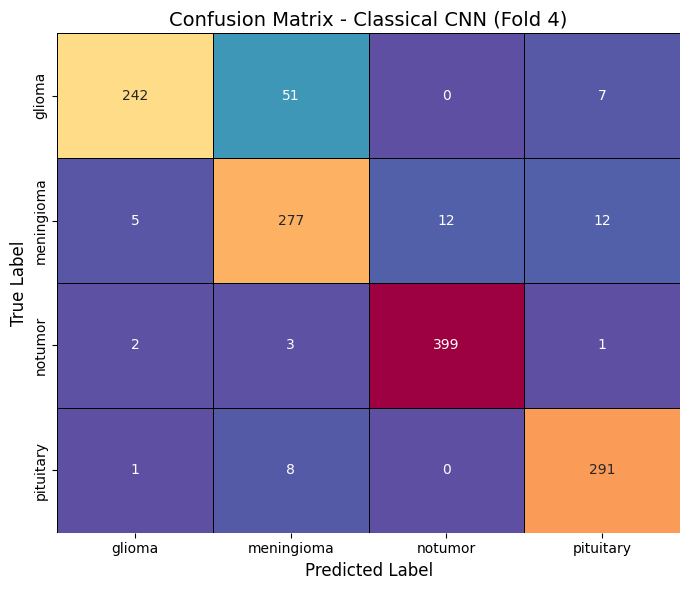


🔍 Evaluating Classical CNN (Fold 5) ...
41/41 ━━━━━━━━━━━━━━━━━━━━ 5s 122ms/step
Classical CNN (Fold 5) Test Accuracy: 0.9298

Classification Report:
              precision    recall  f1-score   support

      glioma       0.96      0.85      0.90       300
  meningioma       0.88      0.86      0.87       306
     notumor       0.93      0.99      0.96       405
   pituitary       0.95      1.00      0.97       300

    accuracy                           0.93      1311
   macro avg       0.93      0.92      0.93      1311
weighted avg       0.93      0.93      0.93      1311



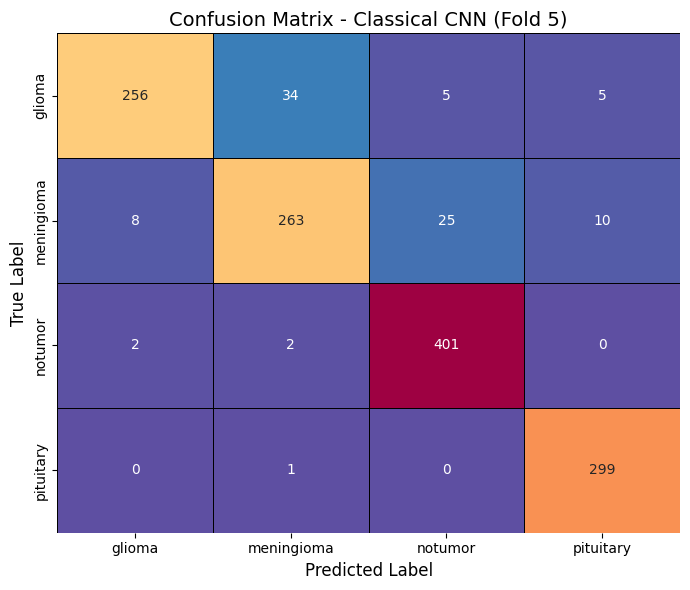

In [13]:
# =======================================================
# 3️⃣ Evaluate Each Model and Generate Visualizations
# =======================================================
for name, model in models.items():
    print(f"\n🔍 Evaluating {name} ...")
    
    # 3.1 Prediction
    test_data.reset() # Reset generator for consistent predictions
    preds = model.predict(test_data, verbose=1)
    y_pred = np.argmax(preds, axis=1)
    y_true = test_data.classes
    
    # 3.2 Accuracy Calculation
    acc = np.mean(y_pred == y_true)
    results[name] = acc
    print(f"{name} Test Accuracy: {acc:.4f}")

    # 3.3 Classification Report (Performance Analysis)
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_labels))

    # 3.4 Confusion Matrix (Performance Visualization)
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Spectral_r', 
                xticklabels=class_labels, yticklabels=class_labels,
                linecolor='black', linewidths=0.5, cbar=False)
    plt.title(f"Confusion Matrix - {name}", fontsize=14)
    plt.xlabel("Predicted Label", fontsize=12)
    plt.ylabel("True Label", fontsize=12)
    plt.tight_layout()
    plt.show()

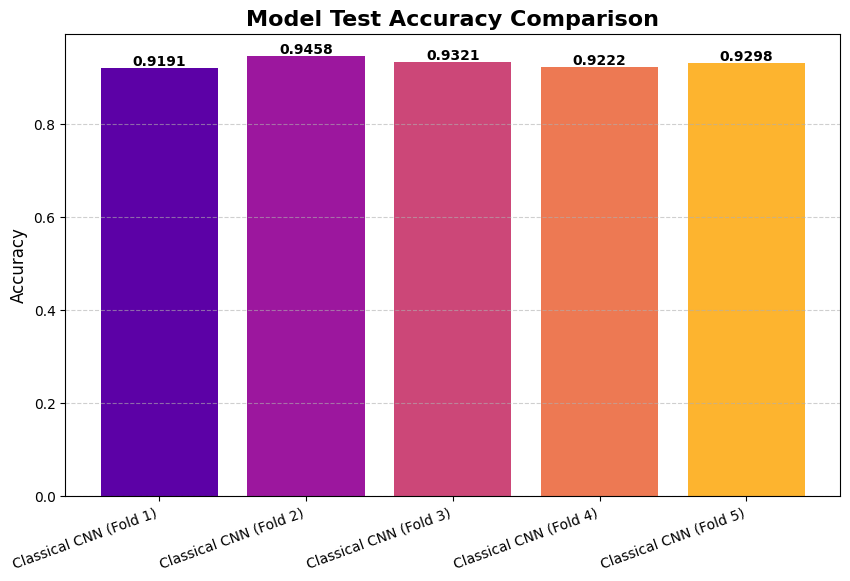

In [14]:
# =======================================================
# 4️⃣ Accuracy Comparison Graph (Result Visualization)
# =======================================================
if results:
    plt.figure(figsize=(10, 6))
    models_names = list(results.keys())
    accuracies = list(results.values())
    colors = sns.color_palette("plasma", len(models_names))

    plt.bar(models_names, accuracies, color=colors)
    plt.title("Model Test Accuracy Comparison", fontsize=16, fontweight='bold')
    plt.ylabel("Accuracy", fontsize=12)
    plt.xticks(rotation=20, ha='right', fontsize=10)
    plt.grid(axis='y', linestyle='--', alpha=0.6)

    for i, acc in enumerate(accuracies):
        plt.text(i, acc + 0.005, f"{acc:.4f}", ha='center', fontweight='bold')
    plt.show()


🧠 SHAP Interpretation for Classical CNN (Fold 1)...


c:\Users\hassa\AppData\Local\Programs\Python\Python312\Lib\site-packages\shap\explainers\_deep\deep_tf.py:99: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn("Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.")


Calculating SHAP values using DeepExplainer...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step

Image 1 | True: glioma | Predicted: glioma


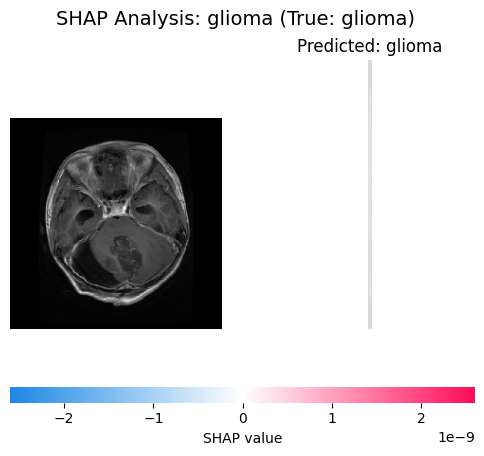

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step

Image 2 | True: glioma | Predicted: glioma


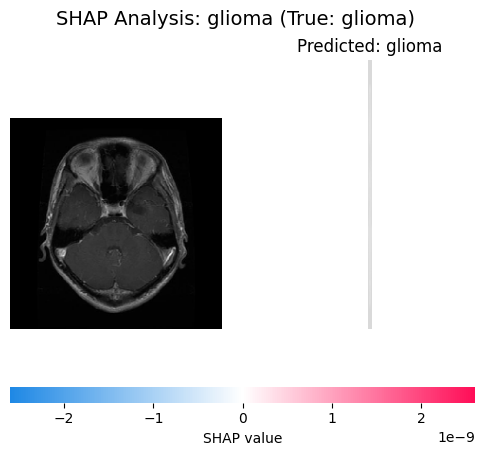

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step

Image 3 | True: glioma | Predicted: glioma


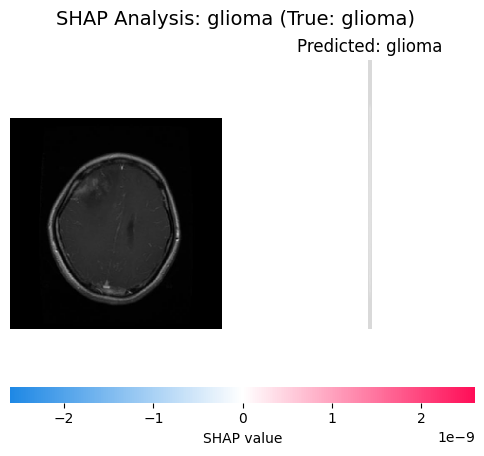

In [16]:
# =======================================================
# 5️⃣ SHAP Visualization (Model Interpretation)
# =======================================================
# Use the first Classical CNN model for SHAP analysis
if "Classical CNN (Fold 1)" in models:
    print("\n🧠 SHAP Interpretation for Classical CNN (Fold 1)...")
    model_to_explain = models["Classical CNN (Fold 1)"]
    num_samples = 50 
    num_images_to_explain = 3
    
    # Prepare data for SHAP Explainer
    test_data.reset()
    X_background = []
    # Collect background data from the generator
    for i in range(int(np.ceil(num_samples / test_data.batch_size))):
        X_batch, _ = next(test_data)  # ✅ Use next() function instead of .next() method
        X_background.extend(X_batch)
        if len(X_background) >= num_samples:
            X_background = np.array(X_background[:num_samples])
            break
    
    # Prepare images to explain
    test_data.reset()
    X_explain, y_cat_explain = next(test_data)  # ✅ Fixed here too
    X_explain = X_explain[:num_images_to_explain]
    y_true_labels = np.argmax(y_cat_explain[:num_images_to_explain], axis=1)

    try:
        # 5.1 Use DeepExplainer for CNNs
        explainer = shap.DeepExplainer(model_to_explain, X_background)
        print("Calculating SHAP values using DeepExplainer...")
        shap_values = explainer.shap_values(X_explain)

        # 5.2 Visualize SHAP results
        for i in range(num_images_to_explain):
            true_label = class_labels[y_true_labels[i]]
            predicted_index = np.argmax(model_to_explain.predict(np.expand_dims(X_explain[i], axis=0)))
            predicted_label = class_labels[predicted_index]

            print(f"\nImage {i+1} | True: {true_label} | Predicted: {predicted_label}")
            
            # Plot SHAP for the predicted class
            # shap_values is a list of arrays, one for each class
            shap.image_plot(
                shap_values[predicted_index], 
                X_explain[i:i+1],  # ✅ Pass as array with shape (1, H, W, C)
                show=False,
                labels=[f"Predicted: {predicted_label}"],
            )
            plt.suptitle(f"SHAP Analysis: {predicted_label} (True: {true_label})", fontsize=14)
            plt.show()

    except Exception as e:
        print(f"\n[ERROR] SHAP DeepExplainer failed. You might need to check TensorFlow/Keras compatibility or use KernelExplainer. Error: {e}")